# Stage 5: Baseline logistic regression PD model

Input: the DuckDB database built by `python -m src.db` (`model_dataset` and
`leakage_demo_dataset` views, `sample_split`). The committed result tables
(`artifacts/model_*.csv`) are written by `python -m src.model`, not by this notebook;
the notebook reproduces and explains the same results.

This notebook:
- reproduces the Stage 5 screening evidence with `assert`s: the `term = 300` x
  `Neg_ammortization` anomaly, the `co-applicant_credit_type` / EQUI proxy, and the
  Information Value screen (decision D-022);
- fits the main model with 5-fold cross-validation on the development sample only
  (D-013), and shows its coefficients (D-023);
- runs a sensitivity check on `lump_sum_payment` outside EQUI;
- compares the main model with the leakage demonstration (D-024).

The hold-out sample is never read in this notebook; see docs/decision_log.md.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, db, eda, model

con = db.connect(config.DUCKDB_PATH)
dev = model.load_development_data(con)  # model_dataset, sample = 'development' only, ordered by ID
dev_ct = model.load_screening_data(con)  # the same rows plus credit_type (for EQUI comparisons only)
outside_equi = dev_ct[dev_ct["credit_type"] != config.EQUI_LEVEL]

print(f"development rows: {len(dev):,}   default rate: {dev[config.TARGET_COL].mean():.4%}")
assert len(dev) == 104_069
assert round(dev[config.TARGET_COL].mean(), 4) == 0.2464

development rows: 104,069   default rate: 24.6442%


## 1. The `term = 300` anomaly (D-022)

`term = 300` defaults at 56.7% overall, far above every other main term (~24%). The
question is whether this is a genuine term effect or an artefact of a small,
unexplained cell -- as with the D-017 pattern.

In [2]:
term_summary = (
    dev_ct.assign(outside_equi=dev_ct["credit_type"] != config.EQUI_LEVEL)
    .groupby("term")[config.TARGET_COL].agg(n="size", default_rate="mean")
    .sort_values("n", ascending=False)
)
print(term_summary.head(6))

cell = outside_equi[(outside_equi["term"] == 300) & (outside_equi["Neg_ammortization"] == "neg_amm")]
rest_300 = outside_equi[(outside_equi["term"] == 300) & (outside_equi["Neg_ammortization"] != "neg_amm")]
print(f"\nterm=300 & neg_amm, outside EQUI: n={len(cell)}, default rate={cell[config.TARGET_COL].mean():.3f}")
print(f"term=300 & not neg_amm, outside EQUI: n={len(rest_300)}, default rate={rest_300[config.TARGET_COL].mean():.3f}")

assert len(cell) == 579
assert round(cell[config.TARGET_COL].mean(), 3) == 0.914
# without the cell, term=300 behaves like every other term
assert rest_300[config.TARGET_COL].mean() < 0.20

           n  default_rate
term                      
360.0  85158      0.241868
180.0   9081      0.243806
240.0   4139      0.209229
300.0   1993      0.566984
324.0   1909      0.252488
120.0    344      0.180233

term=300 & neg_amm, outside EQUI: n=579, default rate=0.914
term=300 & not neg_amm, outside EQUI: n=973, default rate=0.164


**Conclusion:** outside EQUI, almost the entire `term = 300` effect is one small,
unexplained cell (579 loans at 91.4% default). Without it, `term = 300` defaults at
about 16%, the same as everything else. `term` is dropped from the main model; the
cell is documented as a new D-017-type anomaly, not modelled.

## 2. `co-applicant_credit_type` is a proxy for EQUI (D-022)

Almost every EQUI loan has co-applicant type EXP. If the model saw this column, it
would learn a relationship driven by the leakage category, not by borrower risk.

In [3]:
equi_coapplicant = pd.crosstab(dev_ct["credit_type"] == config.EQUI_LEVEL, dev_ct["co-applicant_credit_type"])
print(equi_coapplicant)

rate_all = dev_ct.groupby("co-applicant_credit_type")[config.TARGET_COL].mean()
rate_outside = outside_equi.groupby("co-applicant_credit_type")[config.TARGET_COL].mean()
print("\ndefault rate, all rows:\n", rate_all.round(3))
print("\ndefault rate, outside EQUI:\n", rate_outside.round(3))

assert equi_coapplicant.loc[True, "EXP"] == 10_676
assert equi_coapplicant.loc[True, "CIB"] == 2
# the direction reverses outside EQUI: EXP goes from the higher-risk to the lower-risk level
assert rate_all["EXP"] > rate_all["CIB"]
assert rate_outside["EXP"] < rate_outside["CIB"]

co-applicant_credit_type    CIB    EXP
credit_type                           
False                     52096  41295
True                          2  10676

default rate, all rows:
 co-applicant_credit_type
CIB    0.184
EXP    0.309
Name: Status, dtype: float64

default rate, outside EQUI:
 co-applicant_credit_type
CIB    0.184
EXP    0.130
Name: Status, dtype: float64


**Conclusion:** `co-applicant_credit_type` fails the D-017 admissibility rule (its
values are driven by the leakage category) and is dropped.

## 3. Univariate screen: Information Value (D-022)

Information Value (IV) is computed outside EQUI, on the development sample. Features
below `config.IV_MIN` (0.02, a HEURISTIC) are screened out, in addition to the two
features dropped above for cause.

The screen uses the whole development sample, including the rows each CV fold later
validates on. The CV estimate in section 4 is therefore slightly optimistic (most for
borderline features such as `loan_purpose`, IV 0.0204); the Stage 6 hold-out, which
played no part in screening, is the unbiased check (D-022).

In [4]:
screening = model.screening_table(dev_ct)
pd.set_option("display.width", 200)
print(screening.to_string(index=False))

assert set(screening.loc[screening["kept"], "feature"]) == set(config.MAIN_MODEL_FEATURES)
assert (screening.loc[screening["kept"], "iv_outside_equi"] >= config.IV_MIN).all()

                 feature   iv_all  iv_outside_equi  kept                                                             reason
            income_clean 0.084966         0.157749  True                                       D-022 kept: passes screening
        lump_sum_payment 0.147072         0.137024  True                                       D-022 kept: passes screening
       Neg_ammortization 0.111647         0.132943  True                                       D-022 kept: passes screening
               loan_type 0.043195         0.069763  True                                       D-022 kept: passes screening
             loan_amount 0.036431         0.061289  True                                       D-022 kept: passes screening
                    term 0.050134         0.058096 False D-022 signal is almost all the unexplained term=300 x neg_amm cell
co-applicant_credit_type 0.115057         0.040238 False                  D-022 EQUI proxy; direction reverses outside EQUI
        

## 4. Main model: 5-fold cross-validation and coefficients (D-013, D-023)

Fitted only on the development sample, with the preprocessing (log + standardise the
numerics, most-frequent / median imputation, one-hot encoding) inside a scikit-learn
Pipeline so nothing is fitted on validation data.

In [5]:
X, y = dev[config.MAIN_MODEL_FEATURES], dev[config.TARGET_COL]
model.check_rare_levels(X)  # safeguard: raises if any kept level is too rare (D-023)

pipeline = model.build_pipeline()
cv_metrics, cv_coefficients = model.cross_validate_model(pipeline, X, y)
print(cv_metrics.round(4).to_string(index=False))

final_model = model.fit_final_model(X, y)
coefficients = model.coefficient_table(final_model, X, y, cv_coefficients)
print()
print(coefficients.round(4).to_string(index=False))

mean_auc = cv_metrics.loc[cv_metrics["fold"] == "mean", "auc"].iloc[0]
assert 0.5 < mean_auc < 0.75  # an honest, modest model -- not the near-perfect leakage AUC

fold    auc   gini     ks  brier
   1 0.6485 0.2969 0.2325 0.1710
   2 0.6506 0.3012 0.2397 0.1707
   3 0.6457 0.2915 0.2338 0.1719
   4 0.6580 0.3160 0.2535 0.1700
   5 0.6501 0.3001 0.2347 0.1705
mean 0.6506 0.3011 0.2388 0.1708



                  feature  coefficient  odds_ratio  sm_coefficient  sm_std_error  sm_p_value  expected_sign sign_matches_expected  cv_sign_share
             income_clean      -0.2842      0.7526         -0.2846        0.0101      0.0000           -1.0                  True            1.0
     income_clean_missing      -0.1788      0.8362         -0.1819        0.0361      0.0000            NaN                  None            1.0
              loan_amount       0.0625      1.0645          0.0628        0.0099      0.0000           -1.0                 False            1.0
    lump_sum_payment_lpsm       2.5163     12.3829          2.5150        0.0501      0.0000            1.0                  True            1.0
Neg_ammortization_neg_amm       1.0957      2.9914          1.0940        0.0215      0.0000            1.0                  True            1.0
          loan_type_type2       0.4966      1.6431          0.4984        0.0220      0.0000            1.0                  True

**Reading the coefficients:** `income_clean` and its missing-value flag are negative
(higher income, lower PD), `lump_sum_payment` and `Neg_ammortization` are strongly
positive, and `loan_type = type2` (business/commercial) is positive, all matching
credit intuition (D-022 expected signs). `loan_amount` is positive once `income_clean`
is also in the model (they are correlated at about 0.6 in log scale) -- for a given
income, a larger loan is riskier, which also makes credit sense, but it reverses the
univariate direction. It is kept: for a fixed income it acts as a leverage signal, the only one left in a model without debt-to-income (D-023). The table still shows `sign_matches_expected = False` for it, because the univariate prior is deliberately not rewritten after seeing the result.

## 5. `lump_sum_payment` sensitivity check: refit without EQUI rows

`lpsm` over-represents EQUI loans (34% vs 10% overall), so as a check, the coefficient
is compared with a fit that excludes every EQUI row. If the effect were purely an EQUI
artefact, it should collapse; the modelling decision is to keep `lpsm` regardless,
since it does not.

In [6]:
no_equi = dev_ct[dev_ct["credit_type"] != config.EQUI_LEVEL]
X_no_equi = no_equi[config.MAIN_MODEL_FEATURES]
y_no_equi = no_equi[config.TARGET_COL]

sensitivity_model = model.build_pipeline()
sensitivity_model.fit(X_no_equi, y_no_equi)
sensitivity_coefs = dict(zip(model.feature_names(sensitivity_model), sensitivity_model["model"].coef_.ravel()))
main_lpsm = coefficients.set_index("feature").loc["lump_sum_payment_lpsm", "coefficient"]
print(f"lpsm coefficient, full development sample: {main_lpsm:.3f}")
print(f"lpsm coefficient, outside EQUI only:        {sensitivity_coefs['lump_sum_payment_lpsm']:.3f}")

assert sensitivity_coefs["lump_sum_payment_lpsm"] > 1.0  # still strongly positive

lpsm coefficient, full development sample: 2.516
lpsm coefficient, outside EQUI only:        2.490


## 6. Leakage demonstration (D-024)

Never used on the hold-out sample, for risk grades, monitoring or the dashboard. The
full model adds back every D-017-excluded field; the ablation keeps only whether each
pricing/leakage field is missing, plus `credit_type`. The full model sees the same
missingness (a missing indicator for each numeric field, missing as its own level for
each categorical field), so it is at least as strong as the ablation.

In [7]:
leakage_metrics = model.run_leakage_demo(con)
all_metrics = pd.concat([cv_metrics.assign(model="main"), leakage_metrics], ignore_index=True)
summary = all_metrics[all_metrics["fold"] == "mean"][["model", "auc", "gini", "ks", "brier"]]
print(summary.round(4).to_string(index=False))

auc = summary.set_index("model")["auc"]
assert auc["main"] < 0.75
# Interest_rate_spread is missing iff Status=1 (D-017): both leakage models are (near) perfect
assert auc["leakage_full"] > 0.99 and auc["leakage_ablation_indicators_only"] > 0.99

C:\Users\Bruno\Documents\credit_pd_model\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


C:\Users\Bruno\Documents\credit_pd_model\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


                           model    auc   gini     ks  brier
                            main 0.6506 0.3011 0.2388 0.1708
                    leakage_full 1.0000 1.0000 1.0000 0.0000
leakage_ablation_indicators_only 1.0000 1.0000 1.0000 0.0000


**Conclusion:** both leakage-demonstration models look essentially perfect, far above
the honest main model, and the ablation shows that missingness alone is enough to get
there: the apparent skill comes from how the dataset was assembled, not from borrower
risk. This is the intended illustration of D-017/D-024,
not a model to use.

## 7. Figures

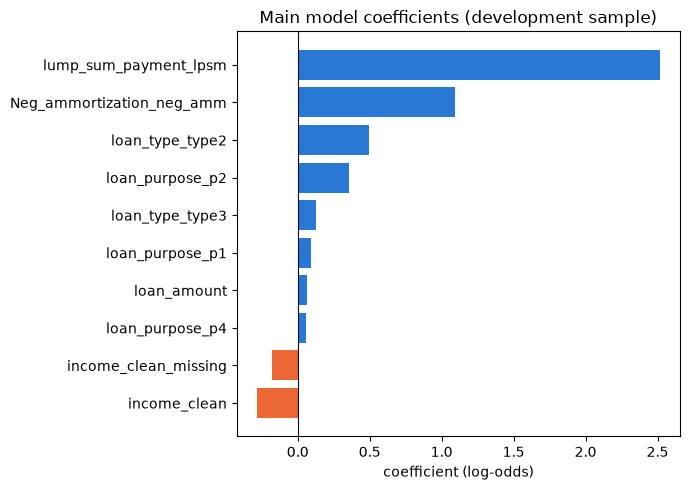

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_coefs = coefficients.set_index("feature")["coefficient"].sort_values()
colors = [config.COLOR_SECONDARY if v < 0 else config.COLOR_PRIMARY for v in plot_coefs]
ax.barh(plot_coefs.index, plot_coefs.values, color=colors)
ax.axvline(0, color=config.COLOR_INK, linewidth=0.8)
ax.set_xlabel("coefficient (log-odds)")
ax.set_title("Main model coefficients (development sample)")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "07_model_coefficients.png", dpi=config.FIGURE_DPI)
plt.show()

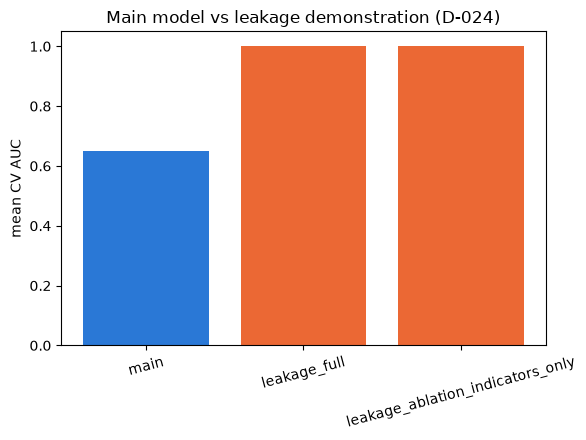

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
order = ["main", "leakage_full", "leakage_ablation_indicators_only"]
aucs = summary.set_index("model").loc[order, "auc"]
ax.bar(order, aucs.values, color=[config.COLOR_PRIMARY, config.COLOR_SECONDARY, config.COLOR_SECONDARY])
ax.set_ylim(0, 1.05)
ax.set_ylabel("mean CV AUC")
ax.set_title("Main model vs leakage demonstration (D-024)")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "08_leakage_demo_auc.png", dpi=config.FIGURE_DPI)
plt.show()

con.close()